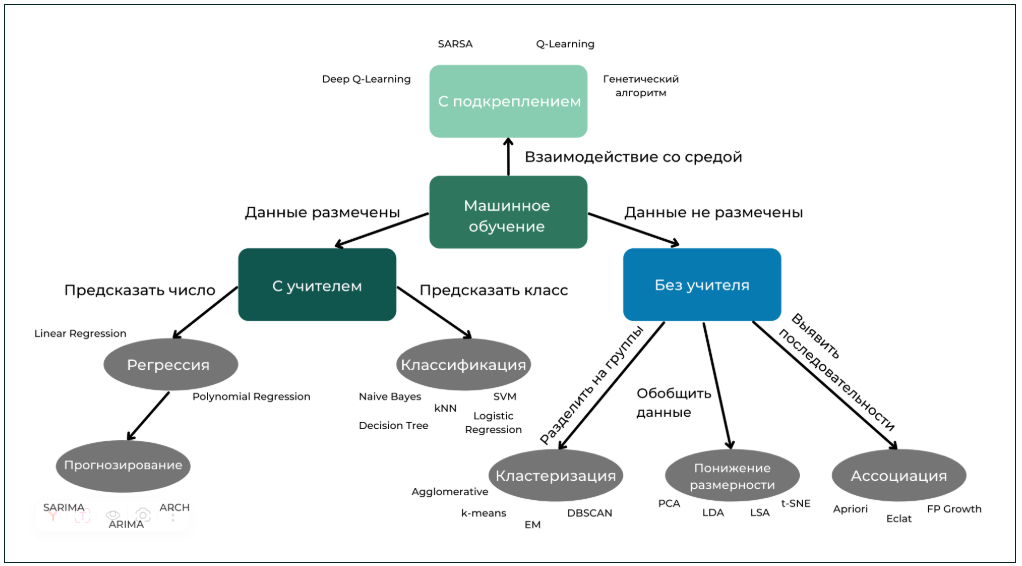

✅ Изображение загружено!


In [7]:
import os
from IPython.display import Image, display

# 1. Либо используйте полный путь напрямую
full_path = r'C:\Users\Admin\Desktop\Обучение skillfactoury\Все виды ML.png'

if os.path.exists(full_path):
    display(Image(filename=full_path))
    print("✅ Изображение загружено!")
else:
    print(f"❌ Файл не найден: {full_path}")
    # Проверим, есть ли файл с другим именем
    folder = r'C:\Users\Admin\Desktop\Обучение skillfactoury'
    if os.path.exists(folder):
        files = os.listdir(folder)
        print(f"Файлы в папке '{folder}':")
        for f in files:
            print(f"  - {f}")


![image.png](attachment:image.png)

# Классификация Нейросетей

### **1. Логистическая регрессия**

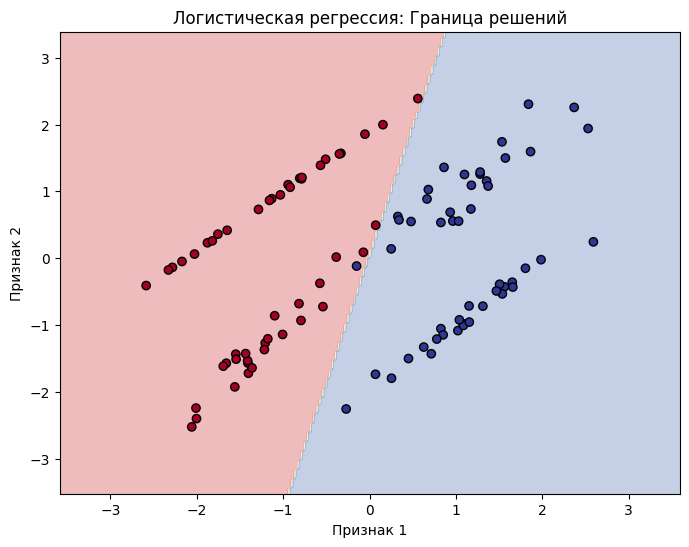

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Данные
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, 
                          n_informative=2, n_redundant=0, random_state=42)

# Модель
model = LogisticRegression()
model.fit(X, y)

# Граница решений
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# График
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k')
plt.title('Логистическая регрессия: Граница решений')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()


In [6]:


### **2. Метод опорных векторов (SVM)**
```python
# SVM С РАЗНЫМИ ЯДРАМИ
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Создаем нелинейные данные
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, kernel in zip(axes, ['linear', 'rbf']):
    model = SVC(kernel=kernel, C=1.0)
    model.fit(X, y)
    
    # Сетка для границы
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'SVM с ядром: {kernel.upper()}')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')

plt.tight_layout()
plt.show()
```

### **3. Дерево решений**
```python
# ДЕРЕВО РЕШЕНИЙ С РАЗНОЙ ГЛУБИНОЙ
from sklearn.tree import DecisionTreeClassifier, plot_tree

X, y = make_classification(n_samples=100, n_features=2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Дерево глубиной 2
model1 = DecisionTreeClassifier(max_depth=2, random_state=42)
model1.fit(X, y)
plot_tree(model1, filled=True, feature_names=['X1', 'X2'], 
          class_names=['Class0', 'Class1'], ax=axes[0])
axes[0].set_title('Дерево глубиной 2')

# Дерево глубиной 4
model2 = DecisionTreeClassifier(max_depth=4, random_state=42)
model2.fit(X, y)
plot_tree(model2, filled=True, feature_names=['X1', 'X2'], 
          class_names=['Class0', 'Class1'], ax=axes[1])
axes[1].set_title('Дерево глубиной 4')

plt.tight_layout()
plt.show()
```

### **4. Наивный байесовский классификатор**
```python
# НАИВНЫЙ БАЙЕС ДЛЯ ТЕКСТОВОГО ПРИМЕРА
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

# Простые текстовые данные
texts = [
    'свободные деньги выигрыш бесплатно',
    'привет как дела встреча завтра',
    'купи сейчас скидка акция',
    'привет друг давно не виделись'
]
labels = [1, 0, 1, 0]  # 1=спам, 0=не спам

# Векторизация текста
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Обучение модели
model = MultinomialNB()
model.fit(X, labels)

# Предсказание
test_text = ["бесплатный выигрыш деньги"]
test_vec = vectorizer.transform(test_text)
prediction = model.predict(test_vec)
probabilities = model.predict_proba(test_vec)

print(f"Текст: '{test_text[0]}'")
print(f"Предсказание: {'СПАМ' if prediction[0]==1 else 'НЕ СПАМ'}")
print(f"Вероятности: [не спам={probabilities[0][0]:.2%}, спам={probabilities[0][1]:.2%}]")
print("\nСлова и их важность для модели:")
for word, idx in vectorizer.vocabulary_.items():
    print(f"{word}: {model.feature_log_prob_[:, idx]}")
```

### **5. Метод ближайших соседей (kNN)**
```python
# kNN С РАЗНЫМ КОЛИЧЕСТВОМ СОСЕДЕЙ
from sklearn.neighbors import KNeighborsClassifier

X, y = make_classification(n_samples=100, n_features=2, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, k in enumerate([1, 3, 5, 10]):
    ax = axes[idx]
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    
    # Граница решений
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
    
    # Показываем соседей для одной точки
    test_point = [[0, 0]]
    distances, indices = model.kneighbors(test_point)
    ax.scatter(test_point[0][0], test_point[0][1], c='red', s=200, marker='*', label='Тестовая точка')
    ax.scatter(X[indices[0], 0], X[indices[0], 1], facecolors='none', edgecolors='red', s=200)
    
    ax.set_title(f'kNN с k={k}')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()
```

---

## 📈 **РЕГРЕССИЯ**

### **6. Линейная регрессия**
```python
# ЛИНЕЙНАЯ РЕГРЕССИЯ
from sklearn.linear_model import LinearRegression

# Создаем данные
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# Модель
model = LinearRegression()
model.fit(X, y)

# Предсказания
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred = model.predict(X_line)

# График
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Данные')
plt.plot(X_line, y_pred, 'r-', linewidth=3, 
         label=f'y = {model.intercept_[0]:.1f} + {model.coef_[0][0]:.1f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Линейная регрессия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

### **7. Полиномиальная регрессия**
```python
# ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ РАЗНЫХ СТЕПЕНЕЙ
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Нелинейные данные
np.random.seed(42)
X = np.random.rand(50, 1) * 10
y = 0.5 * X**2 + X + 2 + np.random.randn(50, 1) * 2

degrees = [1, 2, 3, 5]
colors = ['red', 'blue', 'green', 'purple']

plt.figure(figsize=(12, 8))

for degree, color in zip(degrees, colors):
    # Создаем полиномиальную модель
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    # Предсказания
    X_line = np.linspace(0, 10, 100).reshape(-1, 1)
    y_pred = model.predict(X_line)
    
    plt.plot(X_line, y_pred, color=color, linewidth=2, 
             label=f'Степень {degree}', alpha=0.8)

plt.scatter(X, y, alpha=0.6, color='gray', s=50, label='Данные')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Полиномиальная регрессия разных степеней')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

---

## ⏰ **ВРЕМЕННЫЕ РЯДЫ**

### **8. ARIMA**
```python
# ARIMA МОДЕЛЬ ДЛЯ ВРЕМЕННОГО РЯДА
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Создаем временной ряд
np.random.seed(42)
n = 100
time = pd.date_range(start='2023-01-01', periods=n, freq='D')
data = 50 + 0.5 * np.arange(n) + np.random.randn(n) * 10
series = pd.Series(data, index=time)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. Исходный ряд
axes[0].plot(series, label='Исходный ряд')
axes[0].set_title('Исходный временной ряд')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. ACF и PACF
plot_acf(series, lags=20, ax=axes[1])
axes[1].set_title('Автокорреляционная функция (ACF)')

plot_pacf(series, lags=20, ax=axes[2])
axes[2].set_title('Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

# ARIMA модель
model = ARIMA(series, order=(1, 1, 1))  # (p,d,q)
results = model.fit()

# Прогноз
forecast_steps = 20
forecast = results.forecast(steps=forecast_steps)

# График прогноза
plt.figure(figsize=(12, 6))
plt.plot(series, label='Исторические данные')
plt.plot(forecast.index, forecast, label='Прогноз ARIMA', color='red', linewidth=2)
plt.fill_between(forecast.index, 
                 forecast - 1.96*results.resid.std(), 
                 forecast + 1.96*results.resid.std(), 
                 color='red', alpha=0.2, label='Доверительный интервал')
plt.title('ARIMA: Прогноз временного ряда')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

### **9. SARIMA**
```python
# SARIMA МОДЕЛЬ С СЕЗОННОСТЬЮ
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Создаем ряд с сезонностью
np.random.seed(42)
n = 200
time = pd.date_range(start='2020-01-01', periods=n, freq='M')
trend = 0.1 * np.arange(n)
seasonality = 10 * np.sin(2 * np.pi * np.arange(n) / 12)  # Годовая сезонность
noise = np.random.randn(n) * 5
data = 50 + trend + seasonality + noise
series = pd.Series(data, index=time)

# SARIMA модель
model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# Прогноз
forecast_steps = 36
forecast = results.forecast(steps=forecast_steps)
conf_int = results.get_forecast(steps=forecast_steps).conf_int()

# График
plt.figure(figsize=(14, 8))
plt.plot(series, label='Исторические данные', alpha=0.7)

# Прогноз
forecast_index = pd.date_range(start=series.index[-1], periods=forecast_steps+1, freq='M')[1:]
plt.plot(forecast_index, forecast, label='Прогноз SARIMA', color='red', linewidth=2)
plt.fill_between(forecast_index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% доверительный интервал')

# Компоненты
if hasattr(results, 'plot_components'):
    results.plot_components()
    plt.suptitle('SARIMA: Компоненты ряда')

plt.title('SARIMA: Прогноз с сезонностью')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

### **10. ARCH/GARCH**
```python
# ARCH МОДЕЛЬ ДЛЯ ВОЛАТИЛЬНОСТИ
from arch import arch_model

# Создаем финансовый ряд (возвраты)
np.random.seed(42)
n = 500
returns = np.random.randn(n) * 0.01  # Базовые возвраты

# Добавляем кластеры волатильности
for i in range(100, 200):
    returns[i] = np.random.randn() * 0.05  # Высокая волатильность
    
for i in range(300, 400):
    returns[i] = np.random.randn() * 0.02  # Средняя волатильность

# ARCH модель
model = arch_model(returns * 100, vol='Garch', p=1, q=1)  # Умножаем на 100 для лучшей сходимости
results = model.fit()

# Графики
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Возвраты
axes[0].plot(returns * 100, alpha=0.7)
axes[0].set_title('Дневные возвраты (%)')
axes[0].set_ylabel('Возврат, %')
axes[0].grid(True, alpha=0.3)

# 2. Прогноз волатильности (условное СКО)
conditional_volatility = results.conditional_volatility
axes[1].plot(conditional_volatility, color='orange', alpha=0.7)
axes[1].set_title('Условная волатильность (ARCH)')
axes[1].set_ylabel('Волатильность')
axes[1].grid(True, alpha=0.3)

# 3. Стандартизированные остатки
std_resid = results.resid / results.conditional_volatility
axes[2].plot(std_resid, alpha=0.7)
axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[2].axhline(y=2, color='r', linestyle='--', alpha=0.5)
axes[2].axhline(y=-2, color='r', linestyle='--', alpha=0.5)
axes[2].set_title('Стандартизированные остатки')
axes[2].set_xlabel('Время')
axes[2].set_ylabel('Остатки')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод результатов
print(results.summary())
print("\nКлючевые выводы:")
print(f"1. Средняя волатильность: {conditional_volatility.mean():.2f}%")
print(f"2. Максимальная волатильность: {conditional_volatility.max():.2f}%")
print(f"3. ARCH параметр (α): {results.params['alpha[1]']:.3f}")
print(f"4. GARCH параметр (β): {results.params['beta[1]']:.3f}")
print("5. α + β < 1: модель стационарна" if results.params['alpha[1]'] + results.params['beta[1]'] < 1 
      else "5. Внимание: модель может быть нестационарной")
```

---

## 📋 **ИНСТРУКЦИЯ ПО ЗАПУСКУ:**

1. **Установите зависимости:**
```bash
pip install numpy matplotlib scikit-learn pandas statsmodels arch
```

2. **Запускайте программы по отдельности** (каждая самодостаточна)

3. **Для временных рядов** может потребоваться:
```bash
pip install --upgrade statsmodels
```

Каждая программа:
- Создает искусственные данные для демонстрации
- Обучает модель
- Визуализирует результаты
- Покажает ключевые параметры модели

SyntaxError: invalid syntax (2448120909.py, line 2)